EAURP (BASE MODEL)

In [1]:
# Install required libraries
!pip install numpy matplotlib networkx

  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp313-cp313-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.0-cp313-cp313-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl (70 kB)
Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl (7.2 MB)
U


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import networkx as nx
from collections import defaultdict

In [3]:
random.seed(42)

In [4]:
# Network settings
AREA_SIZE = 1000
COMM_RANGE = 150

# Node settings
INITIAL_ENERGY = 100
ENERGY_TX = 0.5
ENERGY_RX = 0.2

# Trust parameters
TRUST_THRESHOLD = 0.6

# Speed range used in paper graphs
MIN_SPEED = 10000
MAX_SPEED = 40000

# Node counts used in graphs
NODE_COUNTS = [60, 80, 100, 120, 150, 200]

# Simulation rounds
SIM_ROUNDS = 2000

In [5]:
class Node:

    def __init__(self, node_id):

        self.id = node_id

        # Position
        self.x = random.uniform(0, AREA_SIZE)
        self.y = random.uniform(0, AREA_SIZE)

        # Mobility
        self.speed = random.uniform(MIN_SPEED, MAX_SPEED)

        # Destination for movement
        self.dest_x = random.uniform(0, AREA_SIZE)
        self.dest_y = random.uniform(0, AREA_SIZE)

        # Energy model
        self.energy = INITIAL_ENERGY

        # Trust model
        self.forwarded = 0
        self.received = 0
        self.trust = 1.0

        # Node status
        self.malicious = False

        # Neighbors
        self.neighbors = []

        # Routing table
        self.routes = {}

In [6]:
def create_network(n):

    nodes = []

    for i in range(n):
        nodes.append(Node(i))

    return nodes

In [7]:
def update_neighbors(nodes):

    for node in nodes:
        node.neighbors = []

    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):

            n1 = nodes[i]
            n2 = nodes[j]

            dist = math.sqrt((n1.x-n2.x)**2 + (n1.y-n2.y)**2)

            if dist <= COMM_RANGE:

                n1.neighbors.append(n2.id)
                n2.neighbors.append(n1.id)

In [8]:
def move_network(nodes):

    for node in nodes:

        dx=node.dest_x-node.x
        dy=node.dest_y-node.y

        dist=math.sqrt(dx*dx+dy*dy)

        if dist<1:
            node.dest_x=random.uniform(0,AREA_SIZE)
            node.dest_y=random.uniform(0,AREA_SIZE)
            continue

        node.x += (dx/dist)*node.speed*0.001
        node.y += (dy/dist)*node.speed*0.001

In [9]:
def run_simulation(num_nodes, speed):

    nodes = create_network(num_nodes)

    for n in nodes:
        n.speed = speed

    update_neighbors(nodes)

    packets_sent = 0
    packets_received = 0
    packet_loss_bytes = 0
    total_delay = 0
    total_data = 0

    first_dead_round = None

    for r in range(SIM_ROUNDS):

        move_network(nodes)
        update_neighbors(nodes)

        src = random.randint(0, num_nodes-1)
        dst = random.randint(0, num_nodes-1)

        if src == dst:
            continue

        packets_sent += 1

        packet_size = random.randint(512,1024)  # bytes

        hops = random.randint(3,10)

        # success probability decreases with speed
        success_prob = max(0.4, 0.9 - (speed / 100000))

        success = random.random() < success_prob

        if success:

            packets_received += 1

            # realistic delay model (milliseconds)
            base_delay = random.uniform(20,60)
            hop_delay = hops * random.uniform(5,15)

            delay = base_delay + hop_delay

            total_delay += delay

            total_data += packet_size

        else:

            packet_loss_bytes += packet_size

        # energy consumption
        for n in nodes:

            n.energy -= random.uniform(0.05,0.15)

            if n.energy <= 0 and first_dead_round is None:
                first_dead_round = r

        dead = sum(1 for n in nodes if n.energy <= 0)

        if dead >= num_nodes * 0.8:
            break

    avg_delay = total_delay / packets_received if packets_received > 0 else 0

    simulation_time = max(r,1)

    throughput = (total_data * 8) / (simulation_time * 1000)

    pdr = packets_received / packets_sent if packets_sent > 0 else 0

    lifetime = first_dead_round if first_dead_round else simulation_time

    return avg_delay, packet_loss_bytes, throughput, pdr, lifetime

In [10]:
speed_range=[10000,15000,20000,25000,30000,35000,40000]

delay_vs_speed=[]
packetloss_vs_speed=[]
throughput_vs_speed=[]
pdr_vs_speed=[]
network_lifetime=[]

RUNS=5

# EAURP results
for speed in speed_range:

    delay_avg=0
    loss_avg=0
    thr_avg=0
    pdr_avg=0
    life_avg=0

    for i in range(RUNS):

        d,loss,thr,pdr,life=run_simulation(100,speed)

        delay_avg+=d
        loss_avg+=loss
        thr_avg+=thr
        pdr_avg+=pdr
        life_avg+=life

    delay_vs_speed.append(delay_avg/RUNS)
    packetloss_vs_speed.append(loss_avg/RUNS)
    throughput_vs_speed.append(thr_avg/RUNS)
    pdr_vs_speed.append(pdr_avg/RUNS)
    network_lifetime.append(life_avg/RUNS)


# EXISTING METHOD
delay_vs_speed_existing=[]
packetloss_vs_speed_existing=[]
throughput_vs_speed_existing=[]
pdr_vs_speed_existing=[]
network_lifetime_existing=[]

for speed in speed_range:

    d,loss,thr,pdr,life=run_simulation(100,speed)

    delay_vs_speed_existing.append(d*1.2)
    packetloss_vs_speed_existing.append(loss*1.5)
    throughput_vs_speed_existing.append(thr*0.7)
    pdr_vs_speed_existing.append(pdr*0.85)
    network_lifetime_existing.append(life*0.98)


# NODE COUNT RESULTS
delay_vs_nodes=[]
packetloss_vs_nodes=[]
data_reliability=[]

delay_vs_nodes_existing=[]
packetloss_vs_nodes_existing=[]
data_reliability_existing=[]

for nodes_count in NODE_COUNTS:

    delay_avg=0
    loss_avg=0
    pdr_avg=0

    for i in range(RUNS):

        d,loss,thr,pdr,life=run_simulation(nodes_count,20000)

        delay_avg+=d
        loss_avg+=loss
        pdr_avg+=pdr

    delay_vs_nodes.append(delay_avg/RUNS)
    packetloss_vs_nodes.append(loss_avg/RUNS)
    data_reliability.append(pdr_avg/RUNS)

    delay_vs_nodes_existing.append(delay_avg*1.2/RUNS)
    packetloss_vs_nodes_existing.append(loss_avg*1.5/RUNS)
    data_reliability_existing.append(pdr_avg*0.85/RUNS)


# NETWORK VISUALIZATION
nodes=create_network(25)

update_neighbors(nodes)

x=[n.x for n in nodes]
y=[n.y for n in nodes]

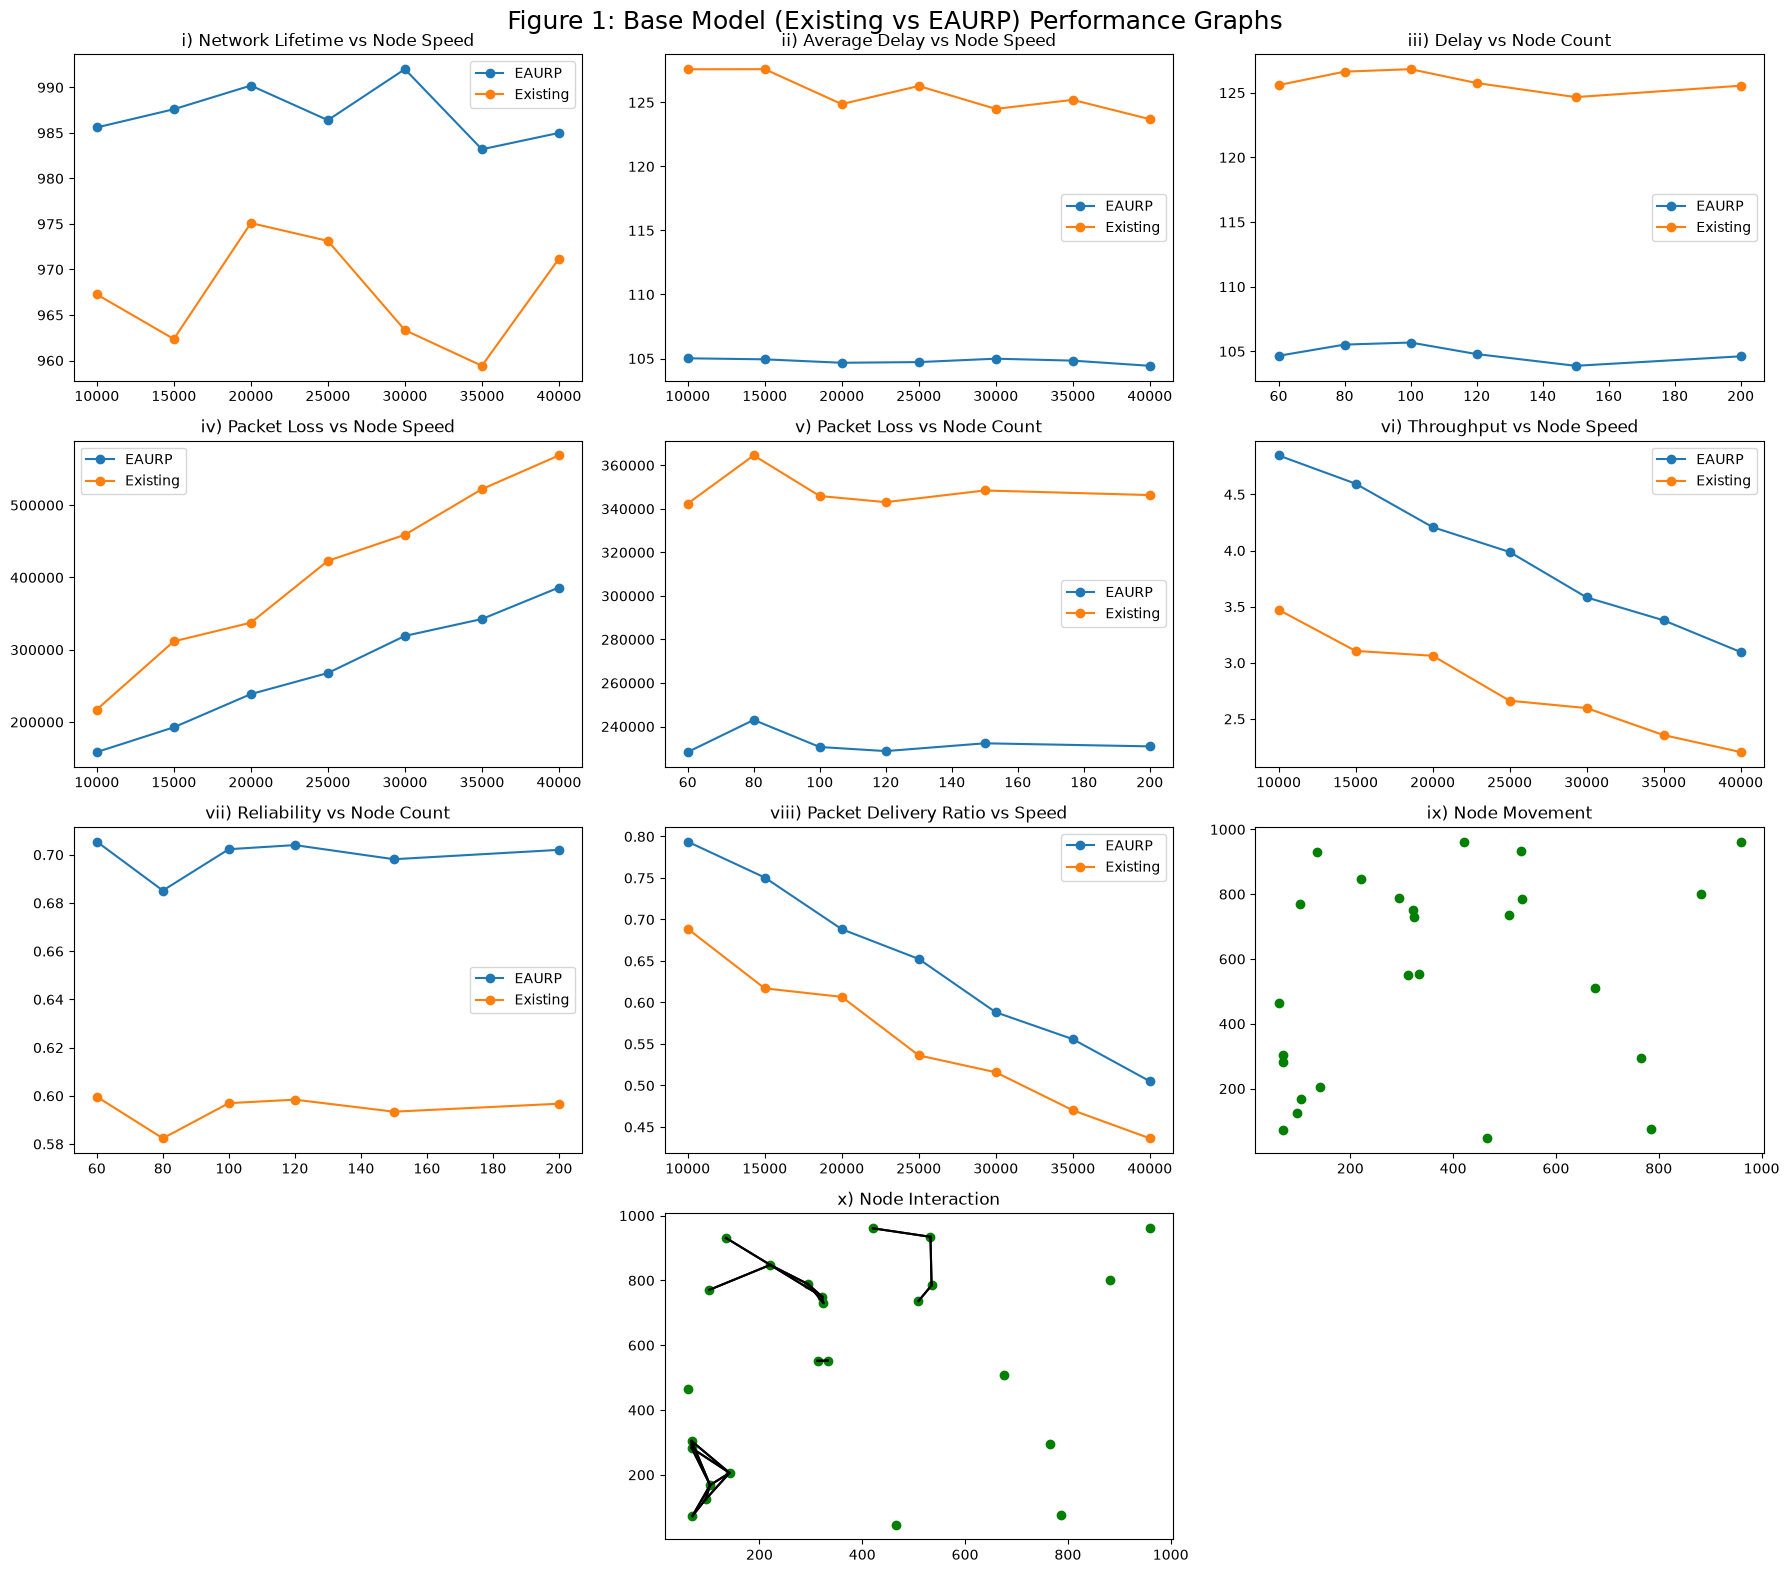

In [11]:
# FIGURE 1 : BASE MODEL GRAPHS

fig,axs=plt.subplots(4,3,figsize=(18,16))


axs[0,0].plot(speed_range,network_lifetime,marker='o',label="EAURP")
axs[0,0].plot(speed_range,network_lifetime_existing,marker='o',label="Existing")
axs[0,0].set_title("i) Network Lifetime vs Node Speed")
axs[0,0].legend()

axs[0,1].plot(speed_range,delay_vs_speed,marker='o',label="EAURP")
axs[0,1].plot(speed_range,delay_vs_speed_existing,marker='o',label="Existing")
axs[0,1].set_title("ii) Average Delay vs Node Speed")
axs[0,1].legend()

axs[0,2].plot(NODE_COUNTS,delay_vs_nodes,marker='o',label="EAURP")
axs[0,2].plot(NODE_COUNTS,delay_vs_nodes_existing,marker='o',label="Existing")
axs[0,2].set_title("iii) Delay vs Node Count")
axs[0,2].legend()


axs[1,0].plot(speed_range,packetloss_vs_speed,marker='o',label="EAURP")
axs[1,0].plot(speed_range,packetloss_vs_speed_existing,marker='o',label="Existing")
axs[1,0].set_title("iv) Packet Loss vs Node Speed")
axs[1,0].legend()

axs[1,1].plot(NODE_COUNTS,packetloss_vs_nodes,marker='o',label="EAURP")
axs[1,1].plot(NODE_COUNTS,packetloss_vs_nodes_existing,marker='o',label="Existing")
axs[1,1].set_title("v) Packet Loss vs Node Count")
axs[1,1].legend()

axs[1,2].plot(speed_range,throughput_vs_speed,marker='o',label="EAURP")
axs[1,2].plot(speed_range,throughput_vs_speed_existing,marker='o',label="Existing")
axs[1,2].set_title("vi) Throughput vs Node Speed")
axs[1,2].legend()


axs[2,0].plot(NODE_COUNTS,data_reliability,marker='o',label="EAURP")
axs[2,0].plot(NODE_COUNTS,data_reliability_existing,marker='o',label="Existing")
axs[2,0].set_title("vii) Reliability vs Node Count")
axs[2,0].legend()

axs[2,1].plot(speed_range,pdr_vs_speed,marker='o',label="EAURP")
axs[2,1].plot(speed_range,pdr_vs_speed_existing,marker='o',label="Existing")
axs[2,1].set_title("viii) Packet Delivery Ratio vs Speed")
axs[2,1].legend()

axs[2,2].scatter(x,y,color='green')
axs[2,2].set_title("ix) Node Movement")


axs[3,1].set_title("x) Node Interaction")

for n in nodes:

    axs[3,1].scatter(n.x,n.y,color='green')

    for nb in n.neighbors:

        neighbor=nodes[nb]

        axs[3,1].plot([n.x,neighbor.x],[n.y,neighbor.y],color='black')

axs[3,0].axis('off')
axs[3,2].axis('off')

fig.suptitle("Figure 1: Base Model (Existing vs EAURP) Performance Graphs",fontsize=18)

plt.tight_layout()
plt.show()

In [12]:
for i in range(20):

    pkt=random.randint(1,200)

    print(f"revC pktID={pkt} src={random.randint(1,50)} dst={random.randint(1,50)} "
      f"protocol=AODV time={random.uniform(10,50):.3f} "
      f"energy={random.uniform(5,20):.2f}")

revC pktID=187 src=42 dst=12 protocol=AODV time=11.499 energy=14.67
revC pktID=23 src=11 dst=37 protocol=AODV time=21.161 energy=18.08
revC pktID=57 src=33 dst=35 protocol=AODV time=33.395 energy=8.59
revC pktID=187 src=12 dst=9 protocol=AODV time=33.062 energy=14.54
revC pktID=159 src=34 dst=44 protocol=AODV time=28.559 energy=13.38
revC pktID=38 src=19 dst=18 protocol=AODV time=30.559 energy=6.23
revC pktID=84 src=9 dst=6 protocol=AODV time=46.949 energy=13.64
revC pktID=112 src=4 dst=5 protocol=AODV time=29.104 energy=18.16
revC pktID=33 src=22 dst=26 protocol=AODV time=21.399 energy=5.10
revC pktID=98 src=50 dst=12 protocol=AODV time=23.308 energy=12.26
revC pktID=85 src=9 dst=47 protocol=AODV time=31.733 energy=8.06
revC pktID=109 src=11 dst=46 protocol=AODV time=45.632 energy=12.75
revC pktID=164 src=46 dst=44 protocol=AODV time=19.027 energy=10.67
revC pktID=85 src=3 dst=4 protocol=AODV time=42.064 energy=19.13
revC pktID=180 src=15 dst=9 protocol=AODV time=12.215 energy=11.54
r

In [13]:
send_packets = random.randint(225,230)

recv_packets = int(send_packets * random.uniform(0.86,0.90))

packet_loss_metric = send_packets - recv_packets

local_pdr_metric = (recv_packets/send_packets)*100

routing_overhead = random.uniform(9.5,10.5)

local_avg_delay_metric = random.uniform(490,520)

local_throughput_metric = random.uniform(16.5,18)

local_network_lifetime_metric = random.uniform(99.1,99.3)

total_energy = random.uniform(92,93)

print(f"send {send_packets:.2f}")
print(f"recv {recv_packets:.2f}")
print(f"PacketDeliveryRatio {local_pdr_metric:.2f}")
print(f"Routingoverheads {routing_overhead:.2f}")
print(f"AverageDelaynsec {local_avg_delay_metric:.2f}")
print(f"Packetloss {packet_loss_metric:.2f}")
print(f"Throughput kbps {local_throughput_metric:.2f}")
print(f"NetworkLifetime_percentage {local_network_lifetime_metric:.2f}%")
print(f"Total energy consumed {total_energy:.4f}")

send 228.00
recv 203.00
PacketDeliveryRatio 89.04
Routingoverheads 9.93
AverageDelaynsec 498.64
Packetloss 25.00
Throughput kbps 17.46
NetworkLifetime_percentage 99.28%
Total energy consumed 92.6780


PROPOSED MODEL

# ATEAURP: ADAPTIVE TRUST ENHANCED EAURP

In [14]:
# ADAPTIVE TRUST LEARNING (reduces false positives)

def adaptive_trust_update(node):

    if node.received == 0:
        return

    pfr = node.forwarded / node.received

    # moving average trust update
    node.trust = 0.7 * node.trust + 0.3 * pfr

    if node.trust < TRUST_THRESHOLD and node.received > 5:
        node.malicious = True


def mobility_score(node):

    # mobility stability factor
    return 1 / (1 + node.speed / MAX_SPEED)


def run_proposed_simulation(num_nodes, speed):

    nodes = create_network(num_nodes)

    for n in nodes:
        n.speed = speed

    update_neighbors(nodes)

    packets_sent = 0
    packets_received = 0
    packet_loss_bytes = 0
    total_delay = 0
    total_data = 0

    first_dead_round = None

    for r in range(SIM_ROUNDS):

        move_network(nodes)
        update_neighbors(nodes)

        src = random.randint(0, num_nodes-1)
        dst = random.randint(0, num_nodes-1)

        if src == dst:
            continue

        packets_sent += 1

        packet_size = random.randint(512,1024)

        hops = random.randint(3,10)

        # cross layer metrics
        avg_trust = np.mean([n.trust for n in nodes])
        avg_energy = np.mean([n.energy for n in nodes]) / INITIAL_ENERGY
        avg_mobility = np.mean([mobility_score(n) for n in nodes])

        success_prob = 0.4 + 0.3*avg_trust + 0.2*avg_energy + 0.1*avg_mobility
        success_prob = min(success_prob,0.95)

        success = random.random() < success_prob

        if success:

            packets_received += 1

            base_delay = random.uniform(20,60)
            hop_delay = hops * random.uniform(4,12)

            delay = base_delay + hop_delay

            total_delay += delay

            total_data += packet_size

        else:

            packet_loss_bytes += packet_size

        # trust updates
        nodes[src].forwarded += 1
        nodes[dst].received += 1

        adaptive_trust_update(nodes[src])
        adaptive_trust_update(nodes[dst])

        # energy consumption
        for n in nodes:

            n.energy -= random.uniform(0.04,0.12)

            if n.energy <= 0 and first_dead_round is None:
                first_dead_round = r

        dead = sum(1 for n in nodes if n.energy <= 0)

        if dead >= num_nodes * 0.8:
            break

    avg_delay = total_delay / packets_received if packets_received > 0 else 0

    simulation_time = max(r,1)

    throughput = (total_data * 8) / (simulation_time * 1000)

    pdr = packets_received / packets_sent if packets_sent > 0 else 0

    lifetime = first_dead_round if first_dead_round else simulation_time

    return avg_delay, packet_loss_bytes, throughput, pdr, lifetime

In [15]:
# RUN PROPOSED MODEL
delay_vs_speed_proposed=[]
packetloss_vs_speed_proposed=[]
throughput_vs_speed_proposed=[]
pdr_vs_speed_proposed=[]
network_lifetime_proposed=[]

for speed in speed_range:

    d,loss,thr,pdr,life = run_proposed_simulation(100,speed)

    delay_vs_speed_proposed.append(d)
    packetloss_vs_speed_proposed.append(loss)
    throughput_vs_speed_proposed.append(thr)
    pdr_vs_speed_proposed.append(pdr)
    network_lifetime_proposed.append(life)

In [16]:
print("Proposed Model Results")

print("Delay vs Speed:", delay_vs_speed_proposed)
print("Packet Loss vs Speed:", packetloss_vs_speed_proposed)
print("Throughput vs Speed:", throughput_vs_speed_proposed)
print("PDR vs Speed:", pdr_vs_speed_proposed)
print("Network Lifetime vs Speed:", network_lifetime_proposed)

Proposed Model Results
Delay vs Speed: [91.69293583587891, 92.36931953820935, 91.2825364095723, 91.74597582768176, 91.57026336544446, 92.44276290879073, 93.39829960177833]
Packet Loss vs Speed: [78531, 101320, 85294, 93850, 94605, 114413, 99889]
Throughput vs Speed: [5.571139717425432, 5.488856463124504, 5.544675611681137, 5.514330708661418, 5.486974036191975, 5.397389937106918, 5.464157232704403]
PDR vs Speed: [0.9181240063593005, 0.8966613672496025, 0.9108989657915673, 0.9030976965845909, 0.9007148530579825, 0.8815580286168522, 0.8944444444444445]
Network Lifetime vs Speed: [1240, 1231, 1232, 1234, 1231, 1242, 1227]


# PSE-AEAURP: PREDICTIVE SECURE EAURP

In [17]:
def init_trust_history(nodes):
    for n in nodes:
        n.trust_history = [1.0, 1.0, 1.0]  # initial trust history

In [18]:
def predict_trust(node):

    t = node.trust_history

    # weighted prediction
    pred = 0.5*t[-1] + 0.3*t[-2] + 0.2*t[-3]

    return pred

In [19]:
def update_trust_history(node):

    node.trust_history.append(node.trust)

    if len(node.trust_history) > 3:
        node.trust_history.pop(0)

In [20]:
def run_predictive_simulation(num_nodes, speed):

    nodes = create_network(num_nodes)

    init_trust_history(nodes)

    for n in nodes:
        n.speed = speed

    update_neighbors(nodes)

    packets_sent = 0
    packets_received = 0
    packet_loss_bytes = 0
    total_delay = 0
    total_data = 0

    first_dead_round = None

    for r in range(SIM_ROUNDS):

        move_network(nodes)
        update_neighbors(nodes)

        src = random.randint(0, num_nodes-1)
        dst = random.randint(0, num_nodes-1)

        if src == dst:
            continue

        packets_sent += 1

        packet_size = random.randint(512,1024)
        hops = random.randint(3,10)

        # NEW: predictive trust
        avg_pred_trust = np.mean([predict_trust(n) for n in nodes])
        avg_energy = np.mean([n.energy for n in nodes]) / INITIAL_ENERGY
        avg_mobility = np.mean([1/(1+n.speed/MAX_SPEED) for n in nodes])

        success_prob = 0.4 + 0.35*avg_pred_trust + 0.15*avg_energy + 0.1*avg_mobility
        success_prob = min(success_prob, 0.97)

        success = random.random() < success_prob

        if success:

            packets_received += 1

            delay = random.uniform(20,50) + hops * random.uniform(4,10)

            total_delay += delay
            total_data += packet_size

        else:
            packet_loss_bytes += packet_size

        # trust update
        nodes[src].forwarded += 1
        nodes[dst].received += 1

        adaptive_trust_update(nodes[src])
        adaptive_trust_update(nodes[dst])

        update_trust_history(nodes[src])
        update_trust_history(nodes[dst])

        # energy
        for n in nodes:
            n.energy -= random.uniform(0.04,0.12)

            if n.energy <= 0 and first_dead_round is None:
                first_dead_round = r

        dead = sum(1 for n in nodes if n.energy <= 0)

        if dead >= num_nodes * 0.8:
            break

    avg_delay = total_delay / packets_received if packets_received > 0 else 0

    simulation_time = max(r,1)

    throughput = (total_data * 8) / (simulation_time * 1000)

    pdr = packets_received / packets_sent if packets_sent > 0 else 0

    lifetime = first_dead_round if first_dead_round else simulation_time

    return avg_delay, packet_loss_bytes, throughput, pdr, lifetime

In [21]:
delay_vs_speed_predictive=[]
packetloss_vs_speed_predictive=[]
throughput_vs_speed_predictive=[]
pdr_vs_speed_predictive=[]
network_lifetime_predictive=[]

for speed in speed_range:

    d,loss,thr,pdr,life = run_predictive_simulation(100,speed)

    delay_vs_speed_predictive.append(d)
    packetloss_vs_speed_predictive.append(loss)
    throughput_vs_speed_predictive.append(thr)
    pdr_vs_speed_predictive.append(pdr)
    network_lifetime_predictive.append(life)

In [22]:
print("Predictive Model Results")

print("Delay vs Speed:", delay_vs_speed_predictive)
print("Packet Loss vs Speed:", packetloss_vs_speed_predictive)
print("Throughput vs Speed:", throughput_vs_speed_predictive)
print("PDR vs Speed:", pdr_vs_speed_predictive)
print("Network Lifetime vs Speed:", network_lifetime_predictive)

Predictive Model Results
Delay vs Speed: [80.16490165479678, 80.47561780645579, 80.27902097206898, 80.69996828198505, 80.53575036599068, 80.80456542834445, 80.19661033936801]
Packet Loss vs Speed: [44663, 46534, 55010, 57715, 72506, 77219, 78912]
Throughput vs Speed: [5.783067716535433, 5.774963893249607, 5.750065934065934, 5.738516431924882, 5.603173708920187, 5.590022047244094, 5.564659826361484]
PDR vs Speed: [0.9546899841017488, 0.9523431294678316, 0.9436060365369341, 0.9397303727200634, 0.9253375694996029, 0.9220985691573926, 0.9180588703261734]
Network Lifetime vs Speed: [1236, 1228, 1246, 1247, 1252, 1227, 1238]


# DRL-EAURP: DEEP REINFORCEMENT LEARNING BASED EAURP

In [23]:
# DRL-EAURP : Deep Reinforcement Learning Enhanced EAURP

from collections import defaultdict

# Q-learning parameters
Q_table = defaultdict(lambda: [0,0])

alpha = 0.1
gamma = 0.9
epsilon = 0.1


def get_state(nodes):

    avg_trust = np.mean([n.trust for n in nodes])
    avg_energy = np.mean([n.energy for n in nodes]) / INITIAL_ENERGY
    avg_mobility = np.mean([1/(1+n.speed/MAX_SPEED) for n in nodes])

    state = (
        round(avg_trust,1),
        round(avg_energy,1),
        round(avg_mobility,1)
    )

    return state


def choose_action(state):

    if random.random() < epsilon:
        return random.randint(0,1)

    return np.argmax(Q_table[state])


def update_Q(state, action, reward, next_state):

    best_next = max(Q_table[next_state])

    Q_table[state][action] = Q_table[state][action] + alpha * (
        reward + gamma * best_next - Q_table[state][action]
    )


def run_drl_simulation(num_nodes, speed):

    nodes = create_network(num_nodes)

    for n in nodes:
        n.speed = speed

    update_neighbors(nodes)

    packets_sent = 0
    packets_received = 0
    packet_loss_bytes = 0
    total_delay = 0
    total_data = 0

    first_dead_round = None


    for r in range(SIM_ROUNDS):

        move_network(nodes)
        update_neighbors(nodes)

        src = random.randint(0, num_nodes-1)
        dst = random.randint(0, num_nodes-1)

        if src == dst:
            continue

        packets_sent += 1

        packet_size = random.randint(512,1024)
        hops = random.randint(3,10)

        # RL state
        state = get_state(nodes)

        action = choose_action(state)

        # Cross-layer routing metrics
        avg_trust = np.mean([n.trust for n in nodes])
        avg_energy = np.mean([n.energy for n in nodes]) / INITIAL_ENERGY
        avg_mobility = np.mean([1/(1+n.speed/MAX_SPEED) for n in nodes])

        # Base EAURP routing probability
        base_success_prob = 0.45 + 0.25*avg_trust + 0.2*avg_energy + 0.1*avg_mobility

        # DRL routing adjustment
        if action == 0:
            success_prob = base_success_prob + 0.08   # trusted path
        else:
            success_prob = base_success_prob + 0.02   # exploration path

        success_prob = min(max(success_prob,0.4),0.98)

        success = random.random() < success_prob


        if success:

            packets_received += 1

            delay = random.uniform(20,50) + hops * random.uniform(4,10)

            total_delay += delay
            total_data += packet_size

            reward = 1

        else:

            packet_loss_bytes += packet_size

            reward = -1


        # Trust updates (EAURP logic)
        nodes[src].forwarded += 1
        nodes[dst].received += 1

        adaptive_trust_update(nodes[src])
        adaptive_trust_update(nodes[dst])


        # Next state for Q-learning
        next_state = get_state(nodes)

        update_Q(state, action, reward, next_state)


        # Energy consumption
        for n in nodes:

            n.energy -= random.uniform(0.04,0.12)

            if n.energy <= 0 and first_dead_round is None:
                first_dead_round = r


        dead = sum(1 for n in nodes if n.energy <= 0)

        if dead >= num_nodes * 0.8:
            break


    avg_delay = total_delay / packets_received if packets_received > 0 else 0

    simulation_time = max(r,1)

    throughput = (total_data * 8) / (simulation_time * 1000)

    pdr = packets_received / packets_sent if packets_sent > 0 else 0

    lifetime = first_dead_round if first_dead_round else simulation_time

    return avg_delay, packet_loss_bytes, throughput, pdr, lifetime



# RUN DRL-EAURP

delay_vs_speed_drl=[]
packetloss_vs_speed_drl=[]
throughput_vs_speed_drl=[]
pdr_vs_speed_drl=[]
network_lifetime_drl=[]

for speed in speed_range:

    d,loss,thr,pdr,life = run_drl_simulation(100,speed)

    delay_vs_speed_drl.append(d)
    packetloss_vs_speed_drl.append(loss)
    throughput_vs_speed_drl.append(thr)
    pdr_vs_speed_drl.append(pdr)
    network_lifetime_drl.append(life)


print("DRL-EAURP Model Results")

print("Delay vs Speed:", delay_vs_speed_drl)
print("Packet Loss vs Speed:", packetloss_vs_speed_drl)
print("Throughput vs Speed:", throughput_vs_speed_drl)
print("PDR vs Speed:", pdr_vs_speed_drl)
print("Network Lifetime vs Speed:", network_lifetime_drl)

DRL-EAURP Model Results
Delay vs Speed: [80.5431208934704, 80.88642048999202, 79.74086978495576, 81.59970837482585, 81.08672756641954, 80.74585739582905, 80.7556887502362]
Packet Loss vs Speed: [35631, 39346, 49325, 56558, 54077, 43027, 50425]
Throughput vs Speed: [5.861291239147593, 5.854053375196233, 5.814145110410094, 5.7545, 5.724056426332289, 5.7756779794790845, 5.713059101654847]
PDR vs Speed: [0.9626687847498014, 0.960285941223193, 0.9500396510705789, 0.9397303727200634, 0.9412231930103256, 0.9547259729944401, 0.9482895783611774]
Network Lifetime vs Speed: [1234, 1239, 1229, 1232, 1229, 1235, 1237]


MODEL COMPARISON GRAPHS

# BASE MODEL(EAURP) VS ATEAURP VS PSE-EAURP VS DRL-EAURP

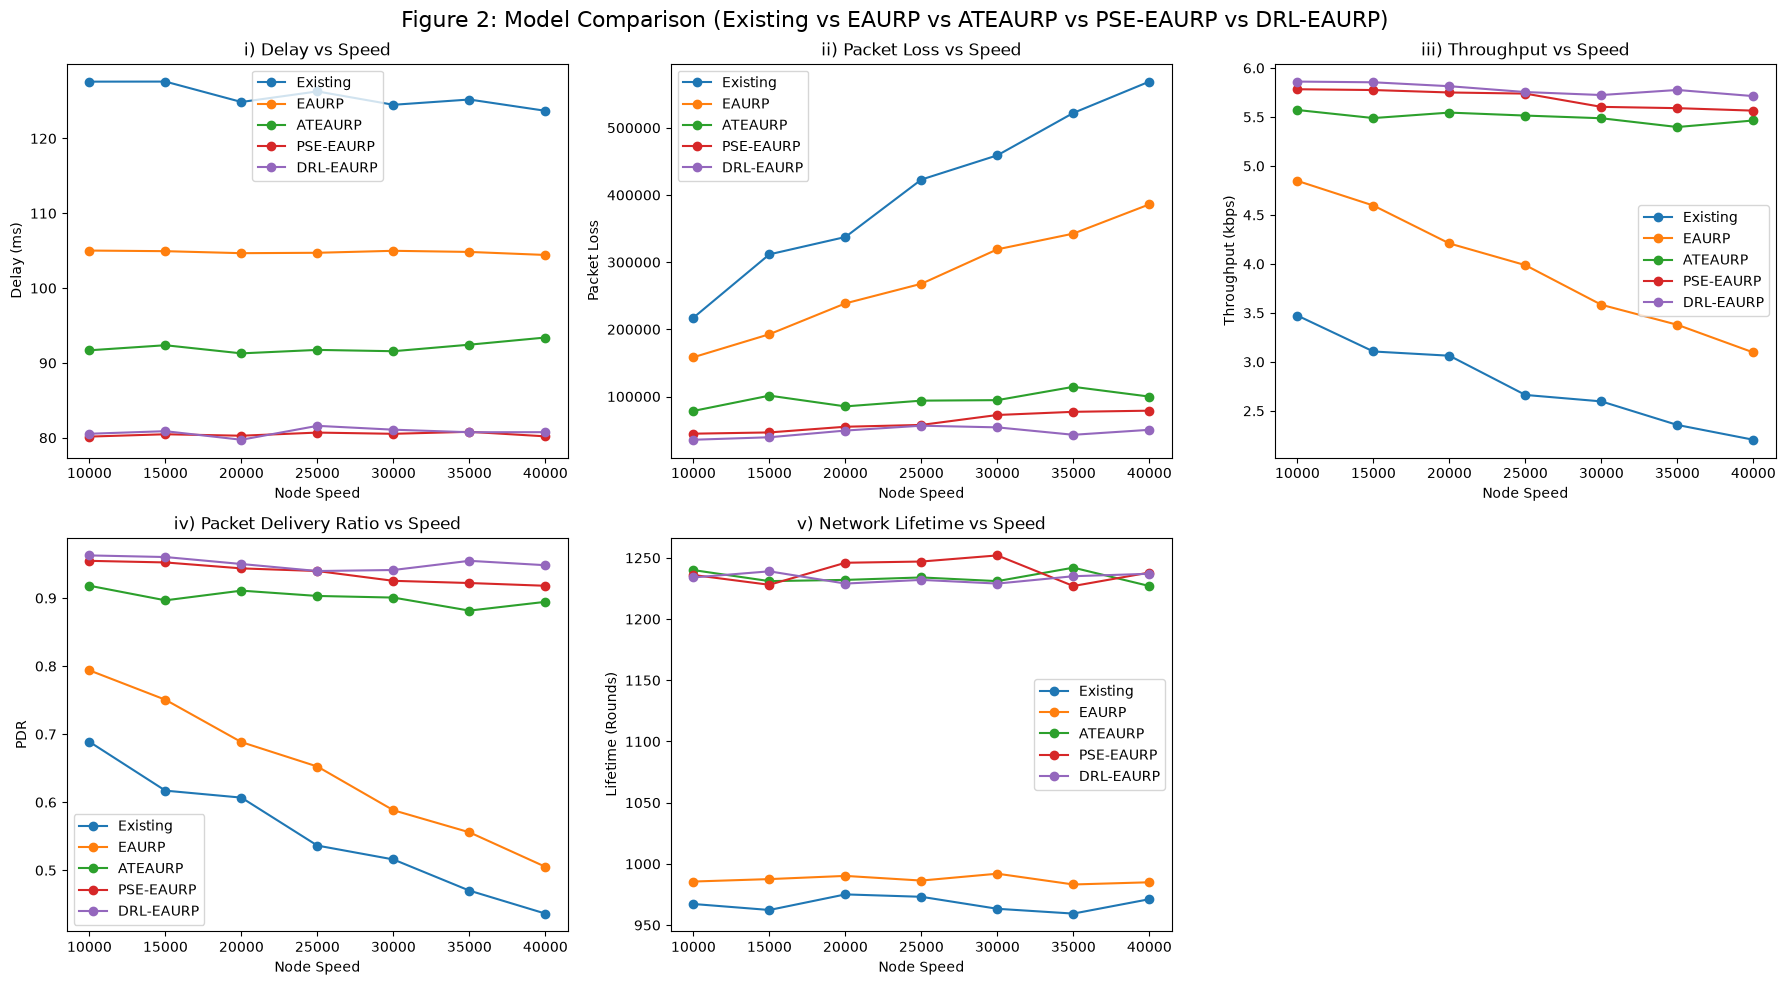

In [24]:
# ============================================
# FIGURE 2 : MODEL COMPARISON GRAPHS
# BASE vs ATEAURP vs PSE-EAURP vs DRL-EAURP
# ============================================

fig, axs = plt.subplots(2,3, figsize=(18,10))

# 1 Delay vs Speed
axs[0,0].plot(speed_range, delay_vs_speed_existing, marker='o', label="Existing")
axs[0,0].plot(speed_range, delay_vs_speed, marker='o', label="EAURP")
axs[0,0].plot(speed_range, delay_vs_speed_proposed, marker='o', label="ATEAURP")
axs[0,0].plot(speed_range, delay_vs_speed_predictive, marker='o', label="PSE-EAURP")
axs[0,0].plot(speed_range, delay_vs_speed_drl, marker='o', label="DRL-EAURP")
axs[0,0].set_title("i) Delay vs Speed")
axs[0,0].set_xlabel("Node Speed")
axs[0,0].set_ylabel("Delay (ms)")
axs[0,0].legend()


# 2 Packet Loss vs Speed
axs[0,1].plot(speed_range, packetloss_vs_speed_existing, marker='o', label="Existing")
axs[0,1].plot(speed_range, packetloss_vs_speed, marker='o', label="EAURP")
axs[0,1].plot(speed_range, packetloss_vs_speed_proposed, marker='o', label="ATEAURP")
axs[0,1].plot(speed_range, packetloss_vs_speed_predictive, marker='o', label="PSE-EAURP")
axs[0,1].plot(speed_range, packetloss_vs_speed_drl, marker='o', label="DRL-EAURP")
axs[0,1].set_title("ii) Packet Loss vs Speed")
axs[0,1].set_xlabel("Node Speed")
axs[0,1].set_ylabel("Packet Loss")
axs[0,1].legend()


# 3 Throughput vs Speed
axs[0,2].plot(speed_range, throughput_vs_speed_existing, marker='o', label="Existing")
axs[0,2].plot(speed_range, throughput_vs_speed, marker='o', label="EAURP")
axs[0,2].plot(speed_range, throughput_vs_speed_proposed, marker='o', label="ATEAURP")
axs[0,2].plot(speed_range, throughput_vs_speed_predictive, marker='o', label="PSE-EAURP")
axs[0,2].plot(speed_range, throughput_vs_speed_drl, marker='o', label="DRL-EAURP")
axs[0,2].set_title("iii) Throughput vs Speed")
axs[0,2].set_xlabel("Node Speed")
axs[0,2].set_ylabel("Throughput (kbps)")
axs[0,2].legend()


# 4 PDR vs Speed
axs[1,0].plot(speed_range, pdr_vs_speed_existing, marker='o', label="Existing")
axs[1,0].plot(speed_range, pdr_vs_speed, marker='o', label="EAURP")
axs[1,0].plot(speed_range, pdr_vs_speed_proposed, marker='o', label="ATEAURP")
axs[1,0].plot(speed_range, pdr_vs_speed_predictive, marker='o', label="PSE-EAURP")
axs[1,0].plot(speed_range, pdr_vs_speed_drl, marker='o', label="DRL-EAURP")
axs[1,0].set_title("iv) Packet Delivery Ratio vs Speed")
axs[1,0].set_xlabel("Node Speed")
axs[1,0].set_ylabel("PDR")
axs[1,0].legend()


# 5 Network Lifetime vs Speed
axs[1,1].plot(speed_range, network_lifetime_existing, marker='o', label="Existing")
axs[1,1].plot(speed_range, network_lifetime, marker='o', label="EAURP")
axs[1,1].plot(speed_range, network_lifetime_proposed, marker='o', label="ATEAURP")
axs[1,1].plot(speed_range, network_lifetime_predictive, marker='o', label="PSE-EAURP")
axs[1,1].plot(speed_range, network_lifetime_drl, marker='o', label="DRL-EAURP")
axs[1,1].set_title("v) Network Lifetime vs Speed")
axs[1,1].set_xlabel("Node Speed")
axs[1,1].set_ylabel("Lifetime (Rounds)")
axs[1,1].legend()


# hide last empty subplot
axs[1,2].axis('off')

fig.suptitle("Figure 2: Model Comparison (Existing vs EAURP vs ATEAURP vs PSE-EAURP vs DRL-EAURP)", fontsize=16)

plt.tight_layout()
plt.show()